In [1]:
!pip install --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 46.6 MB/s eta 0:00:00
  Attempting uninstall: curl_cffi
    Found existing installation: curl_cffi 0.14.0
    Uninstalling curl_cffi-0.14.0:
      Successfully uninstalled curl_cffi-0.14.0
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


[********************* 44%                       ]  4 of 9 completed

[*********************100%***********************]  9 of 9 completed


Ticker           AAPL      BTC-USD     ETH-USD         GLD       MSFT  \
Date                                                                    
2017-11-09  41.003754  7143.580078  320.884003  122.129997  76.777969   
2017-11-10  40.868050  6618.140137  299.252991  121.129997  76.577126   
2017-11-13  40.704269  6559.490234  316.716003  121.309998  76.631897   
2017-11-14  40.088921  6635.750000  337.631012  121.559998  76.741455   
2017-11-15  39.560139  7315.540039  333.356995  121.410004  76.144981   

Ticker          NVDA         QQQ         SPY        USO  
Date                                                     
2017-11-09  5.072605  145.551834  226.694290  91.680000  
2017-11-10  5.339924  145.542328  226.624039  91.360001  
2017-11-13  5.253206  145.722260  226.834747  91.040001  
2017-11-14  5.291499  145.191940  226.307922  89.040001  
2017-11-15  5.187734  144.510071  225.175201  88.720001  


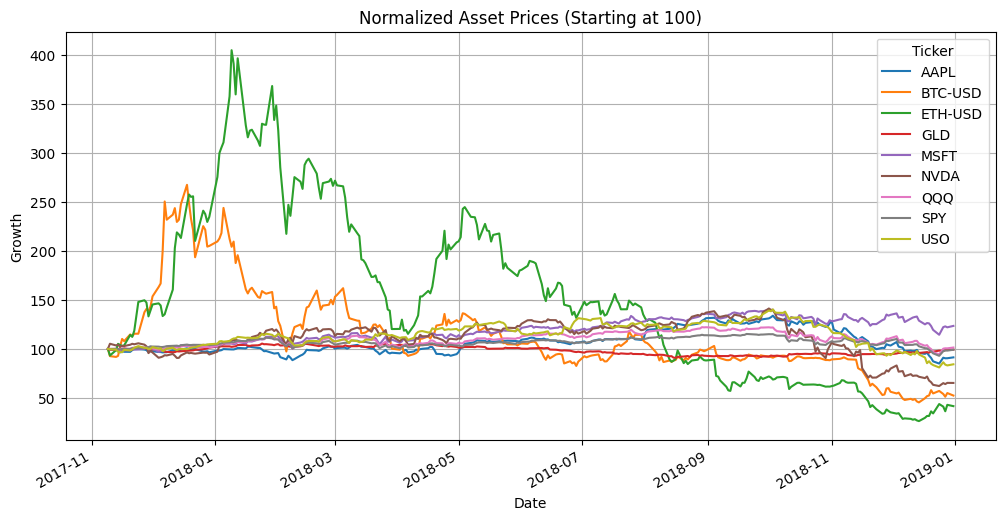


Data saved as 'market_data_raw.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files


# Equities: Apple, Microsoft, Nvidia
# Indices: S&P 500 (SPY), NASDAQ (QQQ)
# Commodities: Gold (GLD), Oil (USO)
# Crypto: Bitcoin (BTC-USD), Ethereum (ETH-USD)
tickers = ['AAPL', 'MSFT', 'NVDA', 'SPY', 'QQQ', 'GLD', 'USO', 'BTC-USD', 'ETH-USD']
start_date = '2012-01-01'
end_date = '2019-01-01'

print("Downloading market data")
all_data = yf.download(tickers, start=start_date, end=end_date)
# We want only the CLose prices of each asset (Since yfinance do not have adj close price)
raw_data = all_data['Close']

clean_data = raw_data.dropna()


print(clean_data.head())

# Plotting a chart to visualize the raw prices
# Normalizing them to start at 100 so they are easy to compare on one chart
(clean_data / clean_data.iloc[0] * 100).plot(figsize=(12, 6), title="Normalized Asset Prices (Starting at 100)")
plt.ylabel("Growth")
plt.xlabel("Date")
plt.grid(True)
plt.show()

clean_data.to_csv('market_data_raw.csv')
print("\nData saved as 'market_data_raw.csv'")
files.download('market_data_raw.csv')

# Calculating Daily Return and Annualized Volatility
Daily Return: $$R_t = \frac{P_t-P_{t-1}} {P_{t-1}}$$

Annualized Volatility:  $$σ_{annual} = σ_{daily} × \sqrt{252}$$


In [8]:
import numpy as np

print("Calculating Returns and Volatility")

# 1. Calculate Daily Percentage Returns
daily_returns = clean_data.pct_change().dropna()

print("\nDaily Percentage Returns (First 5 Days)")
print(daily_returns.head())

# 2. Calculate Annualized Volatility
annual_volatility = daily_returns.std() * np.sqrt(252)

print("\nAnnualized Volatility (Risk)")
# Multiplying by 100 just to make it easier to read as a percentage
print(annual_volatility * 100)

Calculating Returns and Volatility

Daily Percentage Returns (First 5 Days)
Ticker          AAPL   BTC-USD   ETH-USD       GLD      MSFT      NVDA  \
Date                                                                     
2017-11-10 -0.003310 -0.073554 -0.067411 -0.008188 -0.002616  0.052699   
2017-11-13 -0.004008 -0.008862  0.058355  0.001486  0.000715 -0.016240   
2017-11-14 -0.015118  0.011626  0.066037  0.002061  0.001430  0.007289   
2017-11-15 -0.013190  0.102444 -0.012659 -0.001234 -0.007773 -0.019610   
2017-11-16  0.011947  0.076023 -0.007298 -0.000082  0.002651  0.007763   

Ticker           QQQ       SPY       USO  
Date                                      
2017-11-10 -0.000065 -0.000310 -0.003490  
2017-11-13  0.001236  0.000930 -0.003503  
2017-11-14 -0.003639 -0.002323 -0.021968  
2017-11-15 -0.004696 -0.005005 -0.003594  
2017-11-16  0.012780  0.008501 -0.001803  

Annualized Volatility (Risk)
Ticker
AAPL        27.529073
BTC-USD     87.002428
ETH-USD    112.632607
G

# Identifying the different regimes of the market (Bull market or Bear market)

In [9]:
import numpy as np
import pandas as pd

print("Detecting Market Regimes")

# Extract just the S&P 500 (SPY) prices to act as our market thermometer
spy_prices = clean_data['SPY']

# Calculate the 200-Day Moving Average for SPY
spy_sma_200 = spy_prices.rolling(window=200).mean()


# If SPY price > SPY 200-day SMA, label it 1 (Bull). Otherwise, label it -1 (Bear/Crash).
raw_market_regime = np.where(spy_prices > spy_sma_200, 1, -1)

market_regime_series = pd.Series(raw_market_regime, index=spy_prices.index)
final_dataset = daily_returns.copy()
final_dataset['Market_Regime'] = market_regime_series

# Because a 200-day average needs 200 days of history to calculate the very first number, the first 199 rows will be blank (NaN). We just drop them.
final_dataset = final_dataset.dropna()
print("\nFinal Dataset with Market Regimes")
print(final_dataset[['SPY', 'Market_Regime']].head())
print("\nRegime Counts (Days spent in Bull vs. Bear markets):")
print(final_dataset['Market_Regime'].value_counts())

Detecting Market Regimes

Final Dataset with Market Regimes
Ticker           SPY  Market_Regime
Date                               
2017-11-10 -0.000310             -1
2017-11-13  0.000930             -1
2017-11-14 -0.002323             -1
2017-11-15 -0.005005             -1
2017-11-16  0.008501             -1

Regime Counts (Days spent in Bull vs. Bear markets):
Market_Regime
-1    239
 1     46
Name: count, dtype: int64


In [6]:
excel_filename = 'Final_Data.xlsx'

print(f"Exporting data to {excel_filename}...")
final_dataset.to_excel(excel_filename)
files.download(excel_filename)

print("Excel file is downloading now.")

Exporting data to Final_Data.xlsx...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel file is downloading now.
